# HotPotQA ReAct - LangGraph 커스텀 그래프 버전

LangGraph의 `StateGraph`를 사용하여 ReAct 루프를 **명시적 그래프**로 구현한다.  
원본 `hotpotqa.ipynb`의 `webthink()` 로직을 그래프 노드로 충실히 재현한다.

```
START → reasoning → tool_exec ─(continue)─→ reasoning
                        │
                   (done/max_steps)
                        │
                        v
                       END
```

## 1. Setup

In [1]:
import os
import json

from dotenv import load_dotenv
load_dotenv("../.env")

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
import operator

from tools import search, lookup, wiki_state
from eval_utils import load_hotpotqa, normalize_answer, f1_score, get_metrics

## 2. 프롬프트 로딩

In [2]:
with open("../prompts/prompts_naive.json", "r") as f:
    prompt_dict = json.load(f)

webthink_examples = prompt_dict["webthink_simple6"]

INSTRUCTION = """Thought, Action, Observation 단계를 번갈아가며 수행하여 질문 응답 과제를 해결하시오.

Thought는 현재 상황에 대해 추론하는 단계이며,
Action은 다음 세 가지 유형 중 하나여야 한다:

(1) Search[entity]
    Wikipedia에서 해당 entity를 정확히 검색하고, 존재할 경우 첫 번째 문단을 반환한다.
    존재하지 않을 경우, 검색 가능한 유사한 entity 목록을 반환한다.

(2) Lookup[keyword]
    현재 문서에서 해당 keyword가 포함된 다음 문장을 반환한다.

(3) Finish[answer]
    최종 답을 반환하고 과제를 종료한다.

다음은 몇 가지 예시이다.
"""

BASE_PROMPT = INSTRUCTION + webthink_examples
print(f"Base prompt length: {len(BASE_PROMPT)} chars")

Base prompt length: 6261 chars


## 3. 상태 및 LLM 정의

In [3]:
class AgentState(TypedDict):
    question: str
    prompt: str           # 누적 프롬프트 (few-shot + 히스토리)
    current_step: int
    max_steps: int
    answer: str           # 최종 답 (없으면 빈 문자열)
    done: bool
    trajectory: str       # 전체 Thought/Action/Observation 기록
    n_calls: int
    n_badcalls: int


llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0,
    max_tokens=1000,
)

## 4. 그래프 노드 정의

In [4]:
def reasoning_node(state: AgentState) -> dict:
    """LLM을 호출하여 Thought + Action을 생성한다."""
    step = state["current_step"]
    prompt = state["prompt"]

    # Thought + Action 생성
    query = prompt + f"Thought {step}:"
    response = llm.invoke(query, stop=[f"\nObservation {step}:"])
    thought_action = response.content.strip()

    n_calls = state["n_calls"] + 1
    n_badcalls = state["n_badcalls"]

    try:
        thought, action = thought_action.split(f"\nAction {step}: ")
    except ValueError:
        # 파싱 실패 시 Thought만 추출하고 Action을 별도 호출
        n_badcalls += 1
        n_calls += 1
        thought = thought_action.split("\n")[0]
        action_response = llm.invoke(
            prompt + f"Thought {step}: {thought}\nAction {step}:",
            stop=["\n"],
        )
        action = action_response.content.strip()

    # action 첫 글자를 소문자로 (Search -> search)
    if action:
        action = action[0].lower() + action[1:]

    return {
        "prompt": prompt + f"Thought {step}: {thought}\nAction {step}: {action}\n",
        "trajectory": state["trajectory"] + f"Thought {step}: {thought}\nAction {step}: {action}\n",
        "n_calls": n_calls,
        "n_badcalls": n_badcalls,
    }


def tool_exec_node(state: AgentState) -> dict:
    """프롬프트에서 마지막 Action을 파싱하고 실행한다."""
    step = state["current_step"]
    trajectory = state["trajectory"]

    # 마지막 Action 라인 추출
    lines = trajectory.strip().split("\n")
    action_line = ""
    for line in reversed(lines):
        if line.startswith(f"Action {step}:"):
            action_line = line.split(": ", 1)[1] if ": " in line else ""
            break

    action = action_line.strip()

    # Action 실행
    if action.startswith("search[") and action.endswith("]"):
        entity = action[len("search["):-1]
        obs = search.invoke({"entity": entity})
    elif action.startswith("lookup[") and action.endswith("]"):
        keyword = action[len("lookup["):-1]
        obs = lookup.invoke({"keyword": keyword})
    elif action.startswith("finish[") and action.endswith("]"):
        answer = action[len("finish["):-1]
        obs_text = f"Observation {step}: Episode finished.\n"
        return {
            "answer": answer,
            "done": True,
            "prompt": state["prompt"] + obs_text,
            "trajectory": trajectory + obs_text,
            "current_step": step + 1,
        }
    else:
        obs = f"Invalid action: {action}"

    obs = obs.replace("\\n", "")
    obs_text = f"Observation {step}: {obs}\n"

    return {
        "prompt": state["prompt"] + obs_text,
        "trajectory": trajectory + obs_text,
        "current_step": step + 1,
    }


def should_continue(state: AgentState) -> str:
    """그래프 분기: 계속 추론할지, 종료할지 결정한다."""
    if state.get("done", False):
        return "end"
    if state["current_step"] > state["max_steps"]:
        return "end"
    return "continue"


print("Nodes defined.")

Nodes defined.


## 5. 그래프 조립 및 컴파일

In [5]:
graph = StateGraph(AgentState)

# 노드 추가
graph.add_node("reasoning", reasoning_node)
graph.add_node("tool_exec", tool_exec_node)

# 엣지 연결
graph.add_edge(START, "reasoning")
graph.add_edge("reasoning", "tool_exec")
graph.add_conditional_edges(
    "tool_exec",
    should_continue,
    {"continue": "reasoning", "end": END},
)

app = graph.compile()
print("Graph compiled successfully.")

Graph compiled successfully.


## 6. 그래프 시각화 (선택)

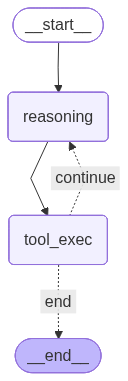

In [6]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph visualization not available: {e}")
    print(app.get_graph().draw_mermaid())

## 7. 실행 함수 정의

In [7]:
def webthink(question: str, idx=None, to_print=True, max_steps=7) -> tuple[dict, dict]:
    """단일 질문에 대해 ReAct 그래프를 실행한다."""
    wiki_state.reset()

    initial_state = {
        "question": question,
        "prompt": BASE_PROMPT + f"Question: {question}\n",
        "current_step": 1,
        "max_steps": max_steps,
        "answer": "",
        "done": False,
        "trajectory": f"Question: {question}\n",
        "n_calls": 0,
        "n_badcalls": 0,
    }

    result = app.invoke(initial_state)

    if to_print:
        if idx is not None:
            print(f"[{idx}] Question: {question}")
        else:
            print(f"Question: {question}")
        print(result["trajectory"])
        print(f"Answer: {result['answer']}")

    info = {
        "answer": result["answer"],
        "n_calls": result["n_calls"],
        "n_badcalls": result["n_badcalls"],
        "trajectory": result["trajectory"],
        "steps": result["current_step"] - 1,
    }
    return result["answer"], info

## 8. 단일 질문 테스트

In [8]:
data = load_hotpotqa("dev")
print(f"Loaded {len(data)} questions.\n")

question, gt_answer = data[0]
pred, info = webthink(question, idx=0)
print(f"\nGT: {gt_answer}")
print(f"Pred: {pred}")
print(f"EM: {normalize_answer(pred) == normalize_answer(gt_answer)}")
print(f"Steps: {info['steps']}, Calls: {info['n_calls']}, BadCalls: {info['n_badcalls']}")

Loaded 7405 questions.

[0] Question: Were Scott Derrickson and Ed Wood of the same nationality?
Question: Were Scott Derrickson and Ed Wood of the same nationality?
Thought 1: Thought 1: I need to search Scott Derrickson and Ed Wood, find their nationalities, then determine if they are the same.

Action 1: search[Scott Derrickson]
Observation 1: Scott Derrickson (born July 16, 1966) is an American filmmaker. He is known for his work in the horror genre, directing films such as The Exorcism of Emily Rose (2005), Sinister (2012), The Black Phone (2021), and its sequel, Black Phone 2 (2025). He is also known for the superhero film Doctor Strange (2016), based on the Marvel Comics character.. Scott Derrickson grew up in Denver, Colorado. He graduated from Biola University with a BA in Humanities with an emphasis in philosophy and literature and a B.A.
Thought 2: Thought 2: Scott Derrickson is American. I need to search Ed Wood and find his nationality to compare.

Action 2: search[Ed Wood

## 10. 배치 평가 (500개 샘플)

In [9]:
import random
import time

idxs = list(range(len(data)))
random.Random(233).shuffle(idxs)

results = []
infos = []
old_time = time.time()

for i, idx in enumerate(idxs[:500]):
    question, gt_answer = data[idx]
    try:
        pred, info = webthink(question, idx=idx, to_print=True)
    except Exception as e:
        print(f"Error at idx {idx}: {e}")
        pred = ""
        info = {"answer": "", "n_calls": 0, "n_badcalls": 0, "trajectory": "", "steps": 0}

    metrics = get_metrics(pred, gt_answer)
    info.update(metrics)
    info["gt_answer"] = gt_answer
    info["question"] = question
    info["question_idx"] = idx

    results.append(metrics)
    infos.append(info)

    em_sum = sum(r["em"] for r in results)
    avg_em = em_sum / len(results)
    elapsed = (time.time() - old_time) / len(results)
    print(f"[{len(results)}/500] EM={em_sum}/{len(results)} ({avg_em:.3f}) | {elapsed:.1f}s/q")
    print(f"GT: {gt_answer}")
    print(f"Pred: {pred}")
    print("-" * 40)
    print()

# 최종 결과
total_em = sum(r["em"] for r in results)
total_f1 = sum(r["f1"] for r in results)
print(f"\n{'='*40}")
print(f"Final Results (LangGraph)")
print(f"{'='*40}")
print(f"EM: {total_em}/{len(results)} ({total_em/len(results):.3f})")
print(f"F1: {total_f1/len(results):.3f}")

[3687] Question: What movie did actress Irene Jacob complete before the American action crime thriller film directed by Stuart Bird?
Question: What movie did actress Irene Jacob complete before the American action crime thriller film directed by Stuart Bird?
Thought 1: Thought 1: The question asks about a movie that actress Irene Jacob completed before an American action crime thriller film directed by Stuart Bird. I need to find the name of the American action crime thriller film directed by Stuart Bird first, then find what movie Irene Jacob completed before that film.

Action 1: search[Stuart Bird]
Observation 1: Could not find Stuart Bird. Similar: ['Stuart Little', 'State Bird Provisions', 'Stuart Keith', 'The Good Lord Bird (miniseries)', 'Flappy Bird'].
Thought 2: Thought 2: Stuart Bird is not found. I need to try searching for "Stuart Bird film" or "Stuart Bird director" to find the American action crime thriller film he directed.

Action 2: search[Stuart Bird film]
Observation

KeyboardInterrupt: 

## 11. 결과 저장

In [ ]:
import os

os.makedirs("trajs", exist_ok=True)
with open("trajs/langgraph_results.json", "w", encoding="utf-8") as f:
    json.dump(infos, f, ensure_ascii=False, indent=2)
print(f"Saved {len(infos)} results to trajs/langgraph_results.json")